E4 Mastery

Brian Bannon

This analysis evaluates the quality and performance of a brake rotor manufacturing process using statistical methods in Python. Key metrics such as Cp and Cpk are calculated to assess process capability, along with defect rates to quantify overall production quality. The study also explores relationships between critical measurements through correlation analysis and visualizations. Results highlight significant process inefficiencies, particularly in centering and variability, which contribute to high defect rates. Based on these findings, targeted improvements are identified to enhance process capability and reduce financial losses.

In [1]:
import pandas as pd
import itertools
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
def calculate_process_capability(
    data: pd.DataFrame, measurement_column: str, lower_spec: float, upper_spec: float) -> dict:
    """
    Function to calculate process capability metrics for a given measurement
    :param data: pandas DataFrame containing production measurements
    :param measurement_column: name of the column to analyze (e.g., 'Thickness_mm')
    :param lower_spec: lower specification limit for the measurement
    :param upper_spec: upper specification limit for the measurement
    :return: dictionary containing Cp, Cpk, mean, standard deviation, and defect rate (ppm)
    """
    column = data[measurement_column]
    mu = column.mean()
    sigma = column.std()
    cp = (upper_spec - lower_spec) / (6 * sigma)
    cpk = min((upper_spec - mu) / (3 * sigma), (mu - lower_spec) / (3 * sigma))
    defect_rate_ppm = ((column < lower_spec) | (column > upper_spec)).sum() / len(column) * 1_000_000

    return {
        'Cp': cp,
        'Cpk': cpk,
        'mean': mu,
        'std': sigma,
        'defect_rate_ppm': defect_rate_ppm
    }

In [3]:
def analyze_measurement_correlations(data: pd.DataFrame, measurements: list[str]) -> tuple:
    """
    Function to analyze correlations between multiple measurement columns
    :param data: pandas DataFrame containing production measurements
    :param measurements: list of column names to include in the correlation analysis
    :return: tuple containing the correlation matrix (DataFrame) and a dictionary with the strongest correlated pair and its coefficient
    """
    columns = data[measurements]
    matrix = columns.corr()
    max_correlation = 0
    strongest_pair = None
    for c1, c2 in itertools.combinations(measurements, 2):
        correlation = abs(matrix.loc[c1, c2])
        if correlation > max_correlation:
            max_correlation = correlation
            strongest_pair = c1, c2
            
    strongest = {'pair': strongest_pair, 'coefficient': matrix.loc[strongest_pair[0], strongest_pair[1]]}

    return matrix, strongest

In [4]:
def generate_quality_report(data: pd.DataFrame, specs: dict) -> pd.DataFrame:
    """
    Function to generate a quality report summarizing process capability for each measurement
    :param data: pandas DataFrame containing production measurements
    :param specs: dictionary mapping each measurement to a tuple of (lower_spec, upper_spec)
    :return: pandas DataFrame summarizing mean, standard deviation, Cp, Cpk, defect rate, and qualitative status for each measurement
    """
    rows = []
    for measurement, (lower, upper) in specs.items():
        result = calculate_process_capability(data, measurement, lower, upper)

        cpk = result['Cpk']
        if cpk >= 1.67:
            status = 'Excellent'
        elif cpk >= 1.33:
            status = 'Good'
        elif cpk >= 1:
            status = 'Marginal'
        else:
            status = 'Poor'

        rows.append({
            'Measurement': measurement,
            'Mean': result['mean'],
            'Std Dev': result['std'],
            'Cp': result['Cp'],
            'Cpk': cpk,
            'Defect Rate (ppm)': result['defect_rate_ppm'],
            'Status': status
        })
    output = pd.DataFrame(rows)
    return output.set_index('Measurement')

In [5]:
data = pd.read_csv('E4_brake_rotor_production.csv')
specs = {
    'Thickness_mm': (11.95, 12.05),
    'Diameter_mm': (299.8, 300.2),
    'Surface_Roughness_um': (0, 1.6),
    'Runout_mm': (0, 0.03)
    }
for i in specs:
    print(i)
    print(calculate_process_capability(data, i, specs[i][0], specs[i][1]))
    print()

Thickness_mm
{'Cp': np.float64(0.27704821173087224), 'Cpk': np.float64(0.2014406465566663), 'mean': np.float64(12.013645200000001), 'std': np.float64(0.060158001246573986), 'defect_rate_ppm': np.float64(368000.0)}

Diameter_mm
{'Cp': np.float64(0.024690773603424677), 'Cpk': np.float64(-0.3532242319087228), 'mean': np.float64(303.06118399999997), 'std': np.float64(2.700063907978), 'defect_rate_ppm': np.float64(731400.0)}

Surface_Roughness_um
{'Cp': np.float64(0.44774012935102153), 'Cpk': np.float64(0.2766395969704989), 'mean': np.float64(1.1057139999999999), 'std': np.float64(0.5955835744568788), 'defect_rate_ppm': np.float64(147400.0)}

Runout_mm
{'Cp': np.float64(0.40323572199196744), 'Cpk': np.float64(0.3212589750062591), 'mean': np.float64(0.01804946), 'std': np.float64(0.012399695084801045), 'defect_rate_ppm': np.float64(119400.0)}



In [6]:
matrix, strongest = analyze_measurement_correlations(data, specs.keys())
matrix, strongest

(                      Thickness_mm  Diameter_mm  Surface_Roughness_um  \
 Thickness_mm              1.000000    -0.266702              0.002392   
 Diameter_mm              -0.266702     1.000000              0.019231   
 Surface_Roughness_um      0.002392     0.019231              1.000000   
 Runout_mm                 0.021085     0.002130              0.329781   
 
                       Runout_mm  
 Thickness_mm           0.021085  
 Diameter_mm            0.002130  
 Surface_Roughness_um   0.329781  
 Runout_mm              1.000000  ,
 {'pair': ('Surface_Roughness_um', 'Runout_mm'),
  'coefficient': np.float64(0.3297809112668966)})

Text(0.5, 1.0, 'Correlation Matrix')

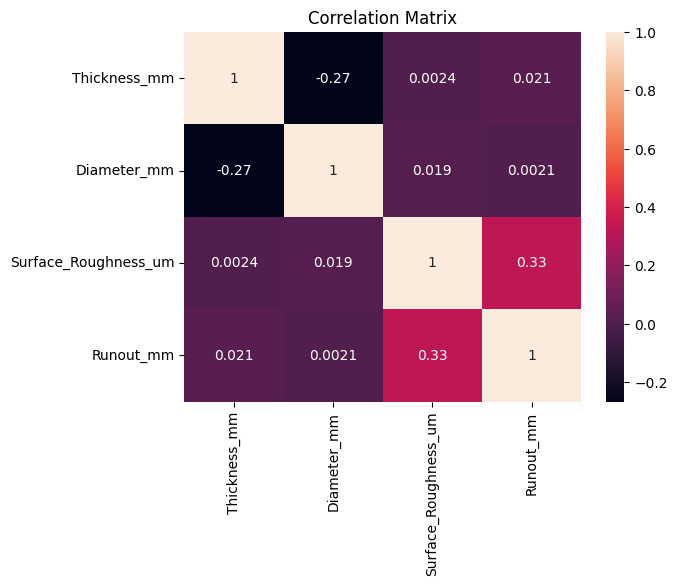

In [7]:
sns.heatmap(matrix, annot=True)
plt.title('Correlation Matrix')

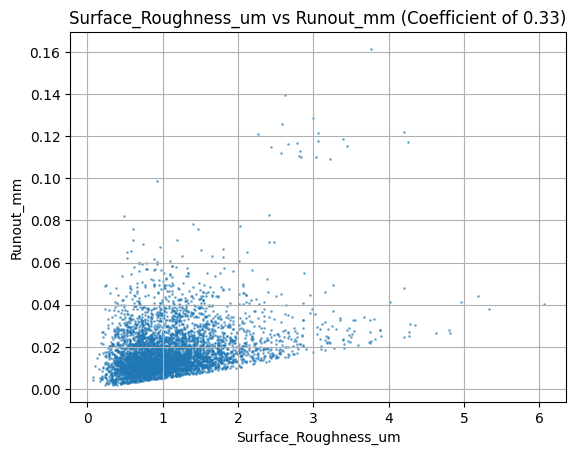

In [8]:
c1, c2 = strongest['pair']
plt.scatter(data[c1], data[c2], s=1, alpha=0.5)
plt.title(f'{c1} vs {c2} (Coefficient of {strongest['coefficient']:.2f})')
plt.xlabel(c1)
plt.ylabel(c2)
plt.grid()

In [9]:
report = generate_quality_report(data, specs)
report

,Mean,Std Dev,Cp,Cpk,Defect Rate (ppm),Status
Measurement,,,,,,
Thickness_mm,12.013645,0.060158,0.277048,0.201441,368000.0,Poor
Diameter_mm,303.061184,2.700064,0.024691,-0.353224,731400.0,Poor
Surface_Roughness_um,1.105714,0.595584,0.447740,0.276640,147400.0,Poor
Runout_mm,0.018049,0.012400,0.403236,0.321259,119400.0,Poor


In [10]:
# Question 2
for i in specs:
    difference = report['Cp'][i] - report['Cpk'][i]
    print(i, difference, difference > 0.2)

Thickness_mm 0.07560756517420594 False
Diameter_mm 0.3779150055121475 True
Surface_Roughness_um 0.17110053238052264 False
Runout_mm 0.08197674698570834 False


In [11]:
# Question 4
any_defect = ((data['Thickness_mm'] < 11.95) | (data['Thickness_mm'] > 12.05) |
              (data['Diameter_mm'] < 299.8) | (data['Diameter_mm'] > 300.2) |
              (data['Surface_Roughness_um'] > 1.6) |
              (data['Runout_mm'] > 0.03))
defective_parts = any_defect.sum()
total_parts = len(data)
rate = defective_parts/len(data)
week = rate * 50_000 * 50
rate, week, week * 52

(np.float64(0.8934), np.float64(2233500.0), np.float64(116142000.0))

QUESTION 1  
Runout has the highest Cpk, indicating it is the most capable and well-centered process among the measurements. Diameter has the lowest Cpk, showing it is the least capable and may require process adjustments to reduce defects and improve centering. Improving Diameter’s mean or reducing variation could significantly increase its capability.

QUESTION 2  
Only Diameter_mm has Cp significantly higher than Cpk (Cp − Cpk ≈ 0.38), indicating the process has enough potential but is off-center. The mean is too high (303.06 mm vs spec center 300.0 mm); shifting the mean down by about 3.06 mm would center the process and maximize Cpk, reducing defects. Other measurements have Cpk close to Cp, so they are reasonably centered.

QUESTION 3  
The correlation matrix shows that most measurement pairs have very low correlations (near 0), indicating that Thickness, Diameter, and Runout are largely independent processes. The only moderate correlation is between Surface_Roughness_um and Runout_mm (0.33), suggesting that rougher surfaces may slightly increase runout, but the effect is not strong. Overall, changes in one measurement are unlikely to strongly affect the others.

QUESTION 4  
The total defect rate across all measurements is approximately 90%, resulting in a weekly scrap cost of about $2.23 million and an annual cost of roughly $116 million. If the worst measurement (Diameter_mm) is improved to a Cpk of 1.33, the defect rate would drop dramatically highlighting the financial impact of centering and stabilizing key processes.

QUESTION 5  
Top priorities should focus on the worst-performing processes: (1) Adjust Diameter_mm tooling to center the mean, expected to raise Cpk from -0.35 saving a lot of money per year; (2) Reduce variation in Thickness_mm through tighter process control, improving Cpk and lowering defects; (3) Optimize Surface_Roughness_um and Runout_mm simultaneously, since their moderate correlation suggests tool wear affects both, which can reduce combined scrap and improve overall process capability. These actions target the largest defect contributors with measurable financial and quality impact.

QUESTION 6  
None of the four measurements currently meet Six Sigma standards. For these processes, improving centering (reducing the Cp–Cpk gap) is most effective for Diameter_mm, while reducing variation (increasing Cp) would benefit Thickness_mm, Surface_Roughness_um, and Runout_mm. If these targeted improvements are implemented, Cpk values could rise above 1.33, dramatically lowering defect rates and approaching industry-acceptable quality levels.

Overall, the analysis reveals that the current manufacturing process is not capable of consistently meeting specification limits, as indicated by low Cp and Cpk values across all measurements. High defect rates further emphasize the need for immediate process improvements, particularly in reducing variation and properly centering key dimensions like diameter. While most measurements operate independently, targeted adjustments can still significantly improve overall quality and reduce scrap. Addressing these issues would not only enhance process capability but also lead to substantial cost savings. With focused improvements, the process has strong potential to reach industry-acceptable performance levels.